# Assignment: Pandas Groupby with Hurricane Data

Import Numpy, Pandas and Matplotlib and set the display options.

In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
%matplotlib inline

Use the following code to load a CSV file of the [NOAA IBTrACS](https://www.ncdc.noaa.gov/ibtracs/index.php?name=ibtracs-data) hurricane dataset:

In [2]:
url = 'https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/csv/ibtracs.ALL.list.v04r01.csv'	

df = pd.read_csv(url, parse_dates=['ISO_TIME'], usecols=range(12),
                 skiprows=[1], na_values=[' ', 'NOT_NAMED'],
                 keep_default_na=False, dtype={'NAME': str})
df.head()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WMO_WIND,WMO_PRES
0,1842298N11080,1842,1,NI,BB,UNNAMED,1842-10-25 03:00:00,NR,10.9,80.3,NaN,NaN
1,1842298N11080,1842,1,NI,BB,UNNAMED,1842-10-25 06:00:00,NR,10.9,79.8,NaN,NaN
2,1842298N11080,1842,1,NI,BB,UNNAMED,1842-10-25 09:00:00,NR,10.8,79.4,NaN,NaN
3,1842298N11080,1842,1,NI,BB,UNNAMED,1842-10-25 12:00:00,NR,10.8,78.9,NaN,NaN
4,1842298N11080,1842,1,NI,BB,UNNAMED,1842-10-25 15:00:00,NR,10.8,78.4,NaN,NaN


Basin Key: (NI - North Indian, SI - South Indian, WP - Western Pacific, SP - Southern Pacific, EP - Eastern Pacific, NA - North Atlantic)

### 1) Orientation 

How many rows does this dataset have? (1 pt)

In [3]:
df.info()
# 723250 rows

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 723250 entries, 0 to 723249
Data columns (total 12 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   SID       723250 non-null  object        
 1   SEASON    723250 non-null  int64         
 2   NUMBER    723250 non-null  int64         
 3   BASIN     723250 non-null  object        
 4   SUBBASIN  723250 non-null  object        
 5   NAME      723250 non-null  object        
 6   ISO_TIME  723250 non-null  datetime64[ns]
 7   NATURE    723250 non-null  object        
 8   LAT       723250 non-null  float64       
 9   LON       723250 non-null  float64       
 10  WMO_WIND  165835 non-null  float64       
 11  WMO_PRES  168843 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(5)
memory usage: 66.2+ MB


How many North Atlantic hurricanes are in this dataset? (1 pt)

In [5]:
atl = df[df.BASIN=='NA']
atl.SID.nunique()

2317

### 2) Get the unique values of the `BASIN`, `SUBBASIN`, and `NATURE` columns
(1 pt)

In [6]:
df.BASIN.unique()

array(['NI', 'SI', 'NA', 'EP', 'WP', 'SP', 'SA'], dtype=object)

In [7]:
df.SUBBASIN.unique()

array(['BB', 'AS', 'MM', 'GM', 'NA', 'CS', 'WA', 'EA', 'CP'], dtype=object)

In [8]:
df.NATURE.unique()

array(['NR', 'TS', 'ET', 'MX', 'SS', 'DS'], dtype=object)

### 3) Rename the `WMO_WIND` and `WMO_PRES` columns to `WIND` and `PRES`
(2 pt)

In [9]:
df = df.rename(columns={"WMO_WIND": "WIND"})
df = df.rename(columns={"WMO_PRES": "PRES"})

### 4) Get the 10 largest rows in the dataset by `WIND`
(2 pt)

In [10]:
df.nlargest(n=10,columns='WIND')

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,WIND,PRES
658946,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 12:00:00,TS,17.3,-105.6,185.0,872.0
658944,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 06:00:00,TS,16.5,-105.4,180.0,886.0
658948,2015293N13266,2015,96,EP,MM,PATRICIA,2015-10-23 18:00:00,TS,18.3,-105.3,180.0,878.0
421320,1980214N11330,1980,55,NA,GM,ALLEN,1980-08-07 18:00:00,TS,21.8,-86.4,165.0,899.0
721707,2025294N14290,2025,95,NA,CS,MELISSA,2025-10-28 12:00:00,TS,17.5,-78.1,165.0,892.0
175293,1935241N23291,1935,45,NA,NA,UNNAMED,1935-09-03 00:00:00,TS,24.6,-80.5,160.0,892.0
175294,1935241N23291,1935,45,NA,NA,UNNAMED,1935-09-03 02:00:00,TS,24.8,-80.8,160.0,892.0
175296,1935241N23291,1935,45,NA,GM,UNNAMED,1935-09-03 06:00:00,TS,25.1,-81.1,160.0,NaN
475882,1988253N12306,1988,73,NA,CS,GILBERT,1988-09-14 00:00:00,TS,19.7,-83.8,160.0,888.0
545774,1997253N12255,1997,75,EP,MM,LINDA,1997-09-12 06:00:00,TS,17.1,-109.6,160.0,902.0


You will notice some names are repeated.

### 5) Group the data on `SID` and get the 10 largest hurricanes by `WIND`
(2 pt)

In [15]:
gb = df.groupby('SID')
gb.WIND.max().nlargest(10)

SID
2015293N13266    185.0
1980214N11330    165.0
2025294N14290    165.0
1935241N23291    160.0
1988253N12306    160.0
1997253N12255    160.0
2005289N18282    160.0
2019236N10314    160.0
1998295N12284    155.0
2005261N21290    155.0
Name: WIND, dtype: float64

### 6) Make a bar chart of the wind speed of the 20 strongest-wind hurricanes

Use the name on the x-axis (hint: group by name)
(4 pt)

Text(0, 0.5, 'Max Wind Speed (m/s)')

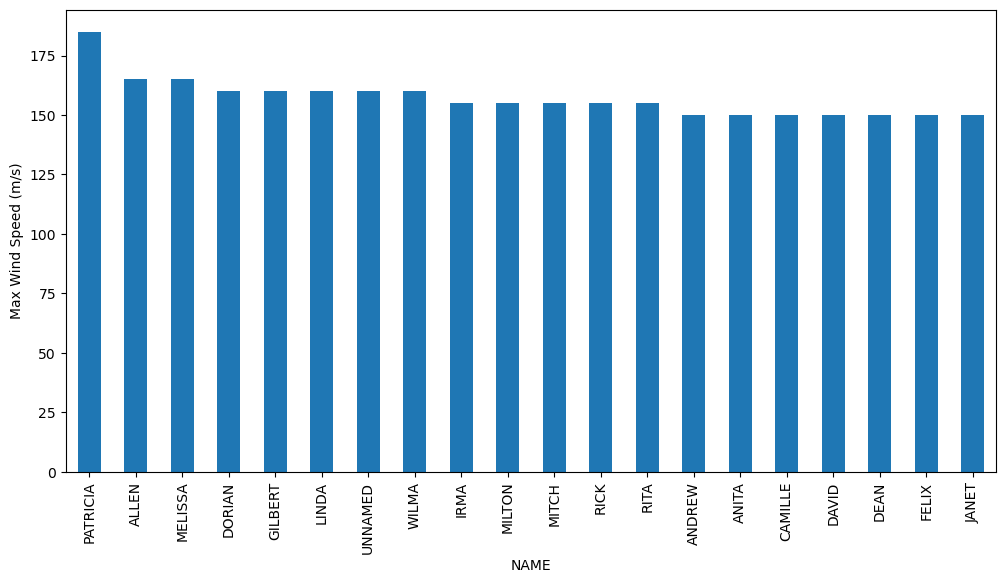

In [16]:
gbn = df.groupby('NAME')
dfw = gbn.WIND.aggregate("max").nlargest(20)
dfw.plot(x='NAME',y='WIND',kind='bar', figsize=(12,6))
plt.ylabel('Max Wind Speed (m/s)')

### 7) Plot the count of all datapoints by Basin

as a bar chart, can use all the variables or just one, label your axes
(2 pt)

<Axes: xlabel='BASIN', ylabel='Number of Data Points'>

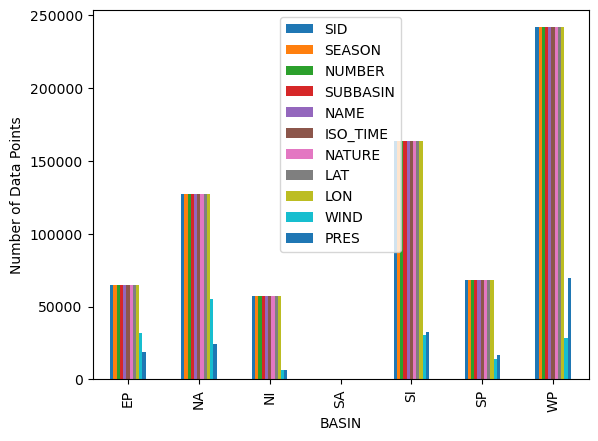

In [17]:
df.groupby('BASIN').count().plot(kind='bar',ylabel='Number of Data Points')


### 8) Plot the count of unique hurricanes by Basin

as a bar chart, label your axes. (2 pts)

Text(0, 0.5, 'Number of unique hurricanes')

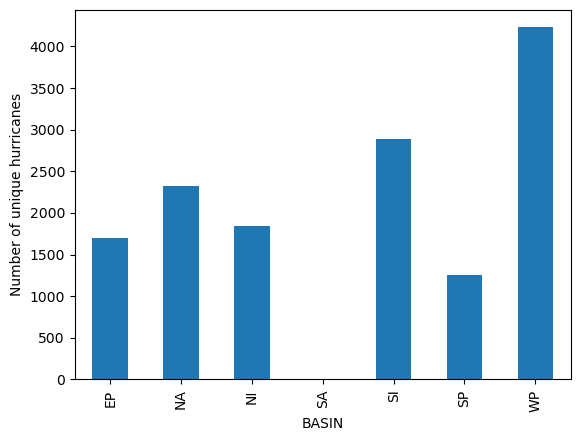

In [18]:
df.groupby('BASIN').SID.nunique().plot(kind='bar')
plt.ylabel('Number of unique hurricanes')

### 9) Make a `hexbin` of the location of datapoints in Latitude and Longitude
(2 pt)

Text(0.5, 1.0, 'Number of Data Points')

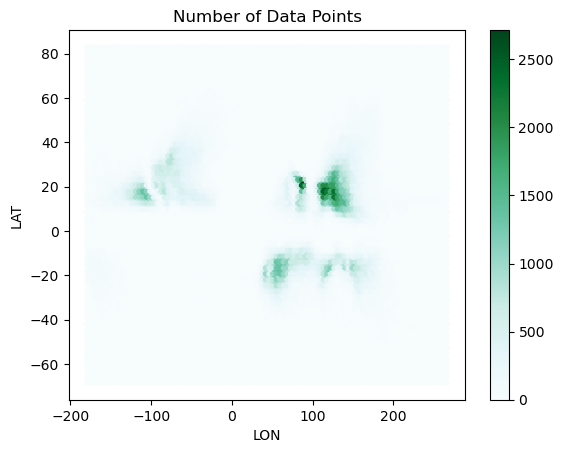

In [19]:
df.plot(x='LON',y='LAT',kind='hexbin')
plt.title('Number of Data Points')

### 10) Find Hurricane Katrina (from 2005) and plot its track as a scatter plot

First find the SID of this hurricane. (2 pt)

In [20]:
sid = df[df.NAME=='KATRINA'].SID.values
sid[-1]

'2005236N23285'

Next get this hurricane's group and plot its position as a scatter plot. Use wind speed to color the points. (2 pt)

<Axes: xlabel='LON', ylabel='LAT'>

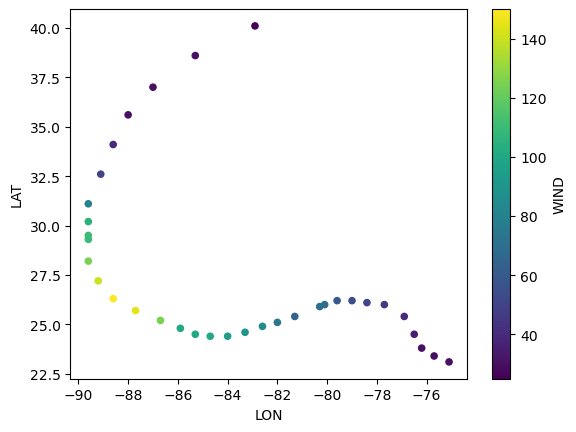

In [21]:
gb1 = df.groupby('SID')
gbkat = gb1.get_group('2005236N23285')
gbkat.plot(x='LON',y='LAT',c='WIND',kind='scatter')

### 11) Make time the index on your dataframe
(2 pt)

In [22]:
df = df.set_index('ISO_TIME')
df.head()

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,NATURE,LAT,LON,WIND,PRES
ISO_TIME,,,,,,,,,,,
1842-10-25 03:00:00,1842298N11080,1842,1,NI,BB,UNNAMED,NR,10.9,80.3,NaN,NaN
1842-10-25 06:00:00,1842298N11080,1842,1,NI,BB,UNNAMED,NR,10.9,79.8,NaN,NaN
1842-10-25 09:00:00,1842298N11080,1842,1,NI,BB,UNNAMED,NR,10.8,79.4,NaN,NaN
1842-10-25 12:00:00,1842298N11080,1842,1,NI,BB,UNNAMED,NR,10.8,78.9,NaN,NaN
1842-10-25 15:00:00,1842298N11080,1842,1,NI,BB,UNNAMED,NR,10.8,78.4,NaN,NaN


### 12) Plot the count of all datapoints per year as a timeseries

You should use `resample` and label your axes (2 pt)

Text(0, 0.5, 'Number of Data Points')

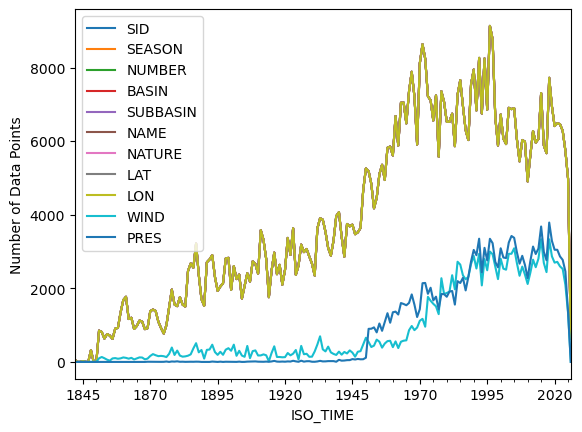

In [23]:
df.resample('YE').count().plot()
plt.ylabel('Number of Data Points')

### 13) Plot all tracks from the North Atlantic in 2005

You will probably have to iterate through a `GroupBy` object
(6 pt)

In [24]:
df05 = df[df.index.year==2005]
df05na = df05[df05.BASIN=='NA']
df05na

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,NATURE,LAT,LON,WIND,PRES
ISO_TIME,,,,,,,,,,,
2005-06-08 18:00:00,2005160N17276,2005,31,NA,CS,ARLENE,TS,16.9,-84.0,25.0,1004.0
2005-06-08 21:00:00,2005160N17276,2005,31,NA,CS,ARLENE,TS,17.1,-83.9,NaN,NaN
2005-06-09 00:00:00,2005160N17276,2005,31,NA,CS,ARLENE,TS,17.4,-83.9,30.0,1003.0
2005-06-09 03:00:00,2005160N17276,2005,31,NA,CS,ARLENE,TS,17.8,-83.9,NaN,NaN
2005-06-09 06:00:00,2005160N17276,2005,31,NA,CS,ARLENE,TS,18.2,-83.9,35.0,1003.0
...,...,...,...,...,...,...,...,...,...,...,...
2005-12-31 09:00:00,2005364N24324,2005,115,NA,NA,ZETA,TS,25.7,-37.8,NaN,NaN
2005-12-31 12:00:00,2005364N24324,2005,115,NA,NA,ZETA,TS,25.7,-37.9,50.0,997.0
2005-12-31 15:00:00,2005364N24324,2005,115,NA,NA,ZETA,TS,25.7,-38.0,NaN,NaN


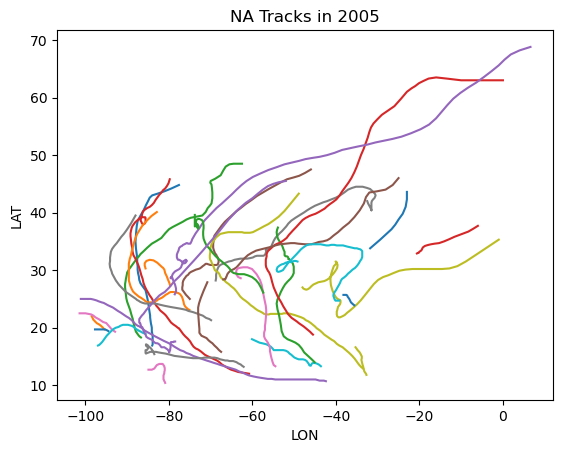

In [25]:
gbtrack = df05na.groupby('SID')
fig, axs = plt.subplots()

for key, group in gbtrack: # DataFrameGroupBy object
    group.plot(x='LON',y='LAT',ax=axs,legend=None,ylabel='LAT',title='NA Tracks in 2005')



### 14) Create a filtered dataframe that contains only data since 1970 from the North Atlantic ("NA") Basin

Use this for the rest of the assignment (2 pt)

In [26]:
df70 = df[df.index.year>=1970]
df70na = df70[df70.BASIN=='NA']


### 15) Plot the number of datapoints per day from this filtered dataframe

Make sure you figure is big enough to actually see the plot (2 pt)

<Axes: xlabel='ISO_TIME', ylabel='Number of Data Points'>

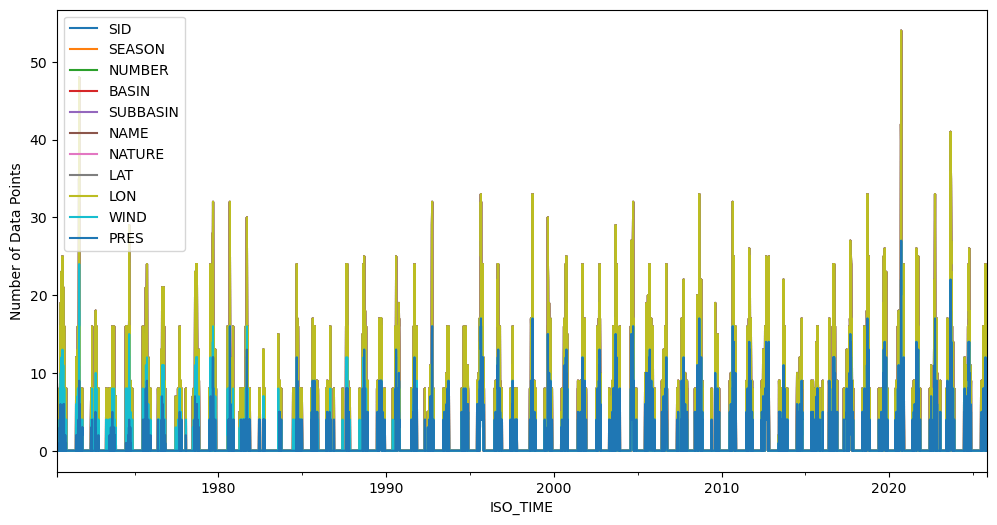

In [27]:
df70na.resample('D').count().plot(ylabel='Number of Data Points',figsize=(12,6))

### 16) Calculate the climatology of datapoint counts as a function of `dayofyear`

Plot the mean and standard deviation on a single figure.  (hint: group by both year and day of year, and choose one variable for the count) (5 pt)

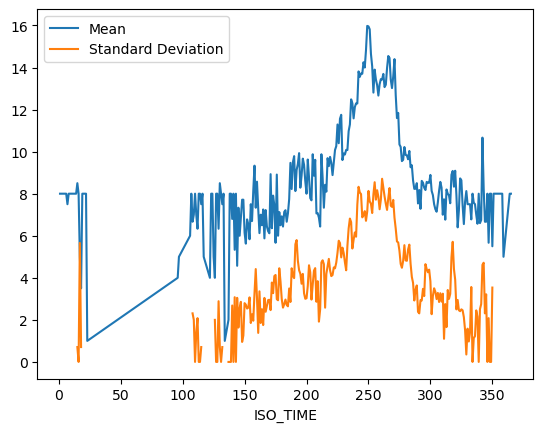

In [29]:
daily_counts = df70na.groupby([df70na.index.year, df70na.index.dayofyear])['SID'].count()

mean_samples = daily_counts.groupby(level=1).mean()
std_samples = daily_counts.groupby(level=1).std()

mean_samples.plot()
std_samples.plot()
plt.legend(['Mean','Standard Deviation'])

## this is fine ...

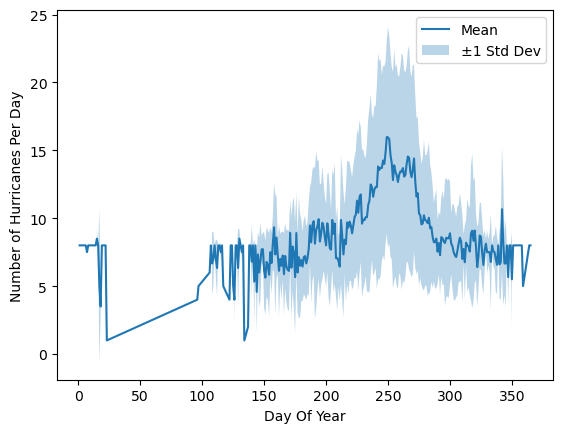

In [31]:
# but this is better

upper = mean_samples + std_samples
lower = mean_samples - std_samples

plt.plot(mean_samples.index, mean_samples, label='Mean')
plt.fill_between(mean_samples.index, lower, upper, alpha=0.3, label='±1 Std Dev')
plt.xlabel('Day Of Year')
plt.ylabel('Number of Hurricanes Per Day')

plt.legend()
plt.show()

### 17) Use `transform` to calculate the anomaly of daily counts from the climatology

Resample the anomaly timeseries at annual resolution and plot a line with dots as markers.  (4 pt)

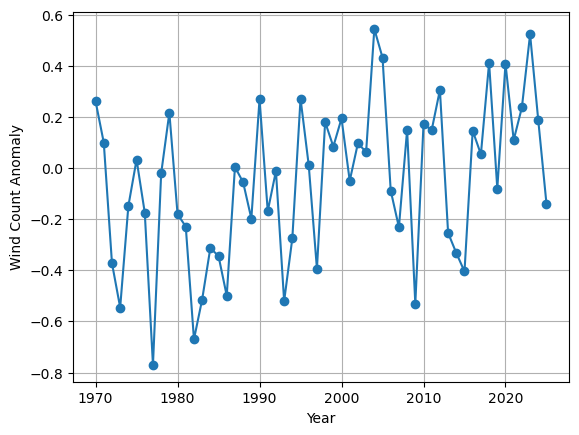

In [40]:
def standardize(x):
    return (x - x.mean())/x.std()

anomaly = daily_counts.groupby(level = 1).transform(standardize)
yearly_anomaly = anomaly.groupby(level=0).mean()
yearly_anomaly.plot(xlabel='Year',marker='o', ylabel='Wind Count Anomaly')
plt.grid()

## There are lots of different ways to do this, and I would grade it a bit leniantly because it is hard.

Which years stand out as having anomalous hurricane activity?

2004, 2005, 2023